In [1]:
import pandas as pd

df = pd.read_csv("../data/sample_music_context.csv")
df.head()


,user_id,track_id,track_name,artist,danceability,energy,valence,tempo,activity_tag,emotion_tag,time_of_day,liked,skipped,replayed
0,u001,t001,Song A,Artist A,0.72,0.81,0.65,120,workout,happy,morning,1,0,1
1,u002,t002,Song B,Artist B,0.45,0.38,0.30,80,study,calm,night,1,0,0
2,u003,t003,Song C,Artist C,0.60,0.70,0.55,100,commute,focus,afternoon,0,1,0
3,u004,t004,Song D,Artist D,0.30,0.25,0.20,70,night,sad,night,1,0,1
4,u005,t005,Song E,Artist E,0.85,0.90,0.80,128,party,happy,night,1,0,1


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       5 non-null      str    
 1   track_id      5 non-null      str    
 2   track_name    5 non-null      str    
 3   artist        5 non-null      str    
 4   danceability  5 non-null      float64
 5   energy        5 non-null      float64
 6   valence       5 non-null      float64
 7   tempo         5 non-null      int64  
 8   activity_tag  5 non-null      str    
 9   emotion_tag   5 non-null      str    
 10  time_of_day   5 non-null      str    
 11  liked         5 non-null      int64  
 12  skipped       5 non-null      int64  
 13  replayed      5 non-null      int64  
dtypes: float64(3), int64(4), str(7)
memory usage: 692.0 bytes


In [3]:
df.describe()

,danceability,energy,valence,tempo,liked,skipped,replayed
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.584000,0.608000,0.500000,99.600000,0.800000,0.200000,0.600000
std,0.216864,0.280482,0.247487,24.915858,0.447214,0.447214,0.547723
min,0.300000,0.250000,0.200000,70.000000,0.000000,0.000000,0.000000
25%,0.450000,0.380000,0.300000,80.000000,1.000000,0.000000,0.000000
50%,0.600000,0.700000,0.550000,100.000000,1.000000,0.000000,1.000000
75%,0.720000,0.810000,0.650000,120.000000,1.000000,0.000000,1.000000
max,0.850000,0.900000,0.800000,128.000000,1.000000,1.000000,1.000000


Matplotlib is building the font cache; this may take a moment.


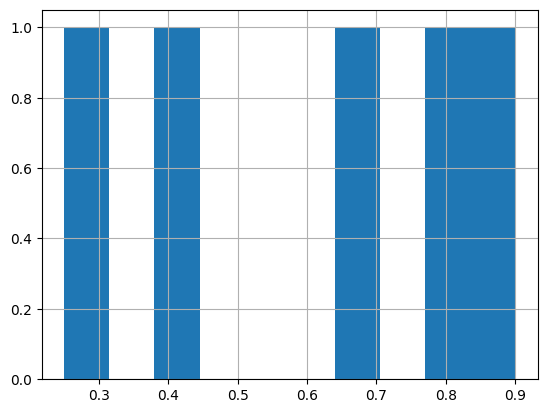

In [4]:
import matplotlib.pyplot as plt

df["energy"].hist()
plt.show()

In [5]:
df["liked"].value_counts()

liked
1    4
0    1
Name: count, dtype: int64

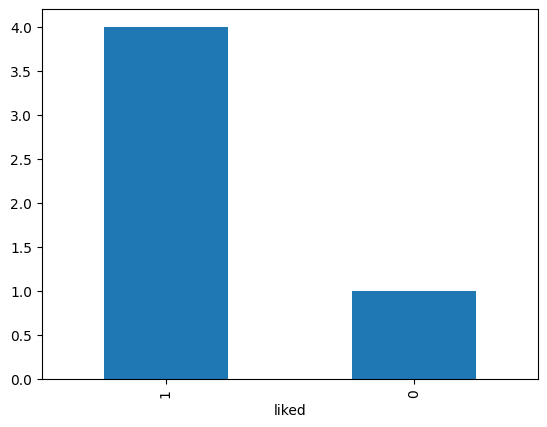

In [6]:
df["liked"].value_counts().plot(kind="bar")
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X=df[["danceability","energy","valence","tempo"]]
y=df["liked"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model=RandomForestClassifier()
model.fit(X_train,y_train)

print(model.score(X_test,y_test))

1.0


In [9]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model.fit(X_train,y_train)

print("Accuracy:",model.score(X_test,y_test))

Accuracy: 1.0


In [10]:
X=df[[
"danceability",
"energy",
"valence",
"tempo",
"activity_tag",
"emotion_tag",
"time_of_day"
]]

In [12]:
context_df = pd.get_dummies(
    df[[
        "activity_tag",
        "emotion_tag",
        "time_of_day"
    ]]
)

context_df.head()

,activity_tag_commute,activity_tag_night,activity_tag_party,activity_tag_study,activity_tag_workout,emotion_tag_calm,emotion_tag_focus,emotion_tag_happy,emotion_tag_sad,time_of_day_afternoon,time_of_day_morning,time_of_day_night
0,False,False,False,False,True,False,False,True,False,False,True,False
1,False,False,False,True,False,True,False,False,False,False,False,True
2,True,False,False,False,False,False,True,False,False,True,False,False
3,False,True,False,False,False,False,False,False,True,False,False,True
4,False,False,True,False,False,False,False,True,False,False,False,True


In [13]:
music_df=df[[
    "danceability",
    "energy",
    "valence",
    "tempo"
]]

X=pd.concat(
    [music_df,context_df],
    axis=1
)

y=df["liked"]

X.head()

,danceability,energy,valence,tempo,activity_tag_commute,activity_tag_night,activity_tag_party,activity_tag_study,activity_tag_workout,emotion_tag_calm,emotion_tag_focus,emotion_tag_happy,emotion_tag_sad,time_of_day_afternoon,time_of_day_morning,time_of_day_night
0,0.72,0.81,0.65,120,False,False,False,False,True,False,False,True,False,False,True,False
1,0.45,0.38,0.30,80,False,False,False,True,False,True,False,False,False,False,False,True
2,0.60,0.70,0.55,100,True,False,False,False,False,False,True,False,False,True,False,False
3,0.30,0.25,0.20,70,False,True,False,False,False,False,False,False,True,False,False,True
4,0.85,0.90,0.80,128,False,False,True,False,False,False,False,True,False,False,False,True


In [14]:
context_df = pd.get_dummies(
    df[[
        "activity_tag",
        "emotion_tag",
        "time_of_day"
    ]]
)

context_df.head()

,activity_tag_commute,activity_tag_night,activity_tag_party,activity_tag_study,activity_tag_workout,emotion_tag_calm,emotion_tag_focus,emotion_tag_happy,emotion_tag_sad,time_of_day_afternoon,time_of_day_morning,time_of_day_night
0,False,False,False,False,True,False,False,True,False,False,True,False
1,False,False,False,True,False,True,False,False,False,False,False,True
2,True,False,False,False,False,False,True,False,False,True,False,False
3,False,True,False,False,False,False,False,False,True,False,False,True
4,False,False,True,False,False,False,False,True,False,False,False,True


In [15]:
music_df=df[[
    "danceability",
    "energy",
    "valence",
    "tempo"
]]

X=pd.concat(
    [music_df,context_df],
    axis=1
)

y=df["liked"]

X.head()

,danceability,energy,valence,tempo,activity_tag_commute,activity_tag_night,activity_tag_party,activity_tag_study,activity_tag_workout,emotion_tag_calm,emotion_tag_focus,emotion_tag_happy,emotion_tag_sad,time_of_day_afternoon,time_of_day_morning,time_of_day_night
0,0.72,0.81,0.65,120,False,False,False,False,True,False,False,True,False,False,True,False
1,0.45,0.38,0.30,80,False,False,False,True,False,True,False,False,False,False,False,True
2,0.60,0.70,0.55,100,True,False,False,False,False,False,True,False,False,True,False,False
3,0.30,0.25,0.20,70,False,True,False,False,False,False,False,False,True,False,False,True
4,0.85,0.90,0.80,128,False,False,True,False,False,False,False,True,False,False,False,True


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model=RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model.fit(X_train,y_train)

print("Accuracy:",model.score(X_test,y_test))

Accuracy: 1.0


In [17]:
print(X.columns)

Index(['danceability', 'energy', 'valence', 'tempo', 'activity_tag_commute',
       'activity_tag_night', 'activity_tag_party', 'activity_tag_study',
       'activity_tag_workout', 'emotion_tag_calm', 'emotion_tag_focus',
       'emotion_tag_happy', 'emotion_tag_sad', 'time_of_day_afternoon',
       'time_of_day_morning', 'time_of_day_night'],
      dtype='str')


In [18]:
print(model.feature_importances_)

[0.05555556 0.05555556 0.05555556 0.11111111 0.16666667 0.
 0.         0.         0.         0.         0.11111111 0.16666667
 0.         0.16666667 0.         0.11111111]


In [19]:
importance_df = pd.DataFrame({
    "feature":X.columns,
    "importance":model.feature_importances_
})

importance_df=importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df

,feature,importance
4,activity_tag_commute,0.166667
11,emotion_tag_happy,0.166667
13,time_of_day_afternoon,0.166667
3,tempo,0.111111
10,emotion_tag_focus,0.111111
15,time_of_day_night,0.111111
1,energy,0.055556
0,danceability,0.055556
2,valence,0.055556
7,activity_tag_study,0.000000


<Axes: xlabel='feature'>

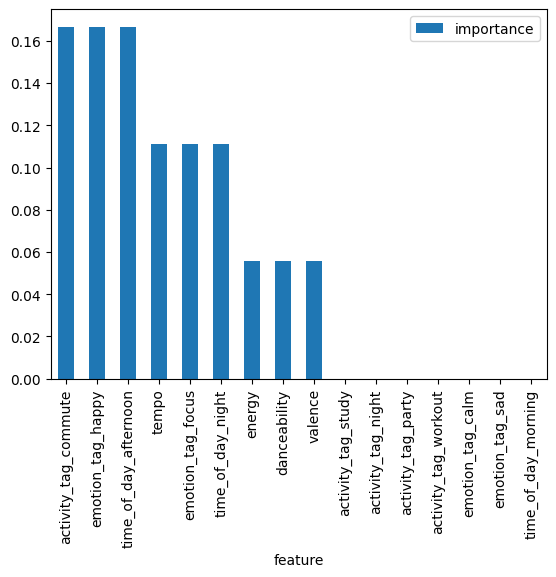

In [20]:
importance_df.plot(
    x="feature",
    y="importance",
    kind="bar"
)

In [21]:
importance_df

,feature,importance
4,activity_tag_commute,0.166667
11,emotion_tag_happy,0.166667
13,time_of_day_afternoon,0.166667
3,tempo,0.111111
10,emotion_tag_focus,0.111111
15,time_of_day_night,0.111111
1,energy,0.055556
0,danceability,0.055556
2,valence,0.055556
7,activity_tag_study,0.000000


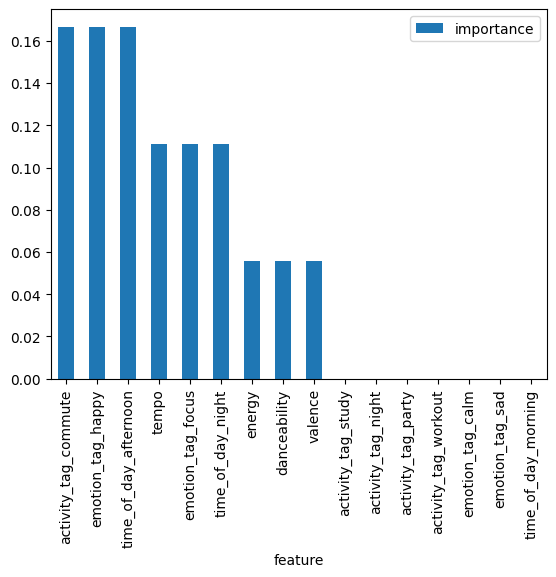

In [23]:
importance_df.plot(
    x="feature",
    y="importance",
    kind="bar"
)

plt.xticks(rotation=90)
plt.show()

| MUGIP_TAGS 정의
   # MUGIP 앱에서 실제 사용하는 Context 태그 목록
   # 이후 One-Hot Encoding을 위해 기준 태그 리스트로 사용
  

In [24]:
MUGIP_TAGS = [
    "Now",
    "Moving",
    "Memories",
    "Random",
    "Rest",
    "Getting Ready",
    "Workout",
    "Running",
    "Studying",
    "Cafe",
    "Travel",
    "School",
    "Reading",
    "Off Work",
    "Party",
    "Beach",
    "Club",
    "Korea",
    "Tokyo",
    "U.S.A",
    "AirPods",
    "Karaoke",
    "Band",
    "Mountain",
    "Driving",
    "On the Road"
]

In [27]:
df = pd.read_csv("../data/sample_music_context.csv")
df.columns

Index(['track_id', 'track_name', 'artist_name', 'danceability', 'energy',
       'valence', 'tempo', 'context_tags', 'liked'],
      dtype='str')

In [32]:
# One-Hot Encoding  생성 
for tag in MUGIP_TAGS:
    df[f"tag_{tag}"] = df["context_tags"].apply(
        lambda x: 1 if tag in str(x).split(",") else 0
    )

# context_tags(예: "Now,Workout")를 분리하여
# 각 태그별 존재 여부를 0/1 feature로 변환


#tag_count 생성
df["tag_count"] = df["context_tags"].apply(
    lambda x: len(str(x).split(","))
)

# 사용자가 몇 개 태그를 선택했는지 계산
# 태그 개수 자체도 사용자 행동 특징(feature)으로 사용

#primary_tag 생성
df["primary_tag"] = df["context_tags"].apply(
    lambda x: str(x).split(",")[0]
)

# 사용자가 가장 먼저 선택한 대표 태그 저장
# 향후 추천 우선순위 분석용으로 활용 가능

df.head()

,track_id,track_name,artist_name,danceability,energy,valence,tempo,context_tags,liked,tag_Now,...,tag_Korea,tag_Tokyo,tag_U.S.A,tag_AirPods,tag_Karaoke,tag_Band,tag_Mountain,tag_Driving,tag_On the Road,primary_tag
0,1,RUDE!,Hearts2Hearts,0.72,0.81,0.76,128,"Now,Workout",1,1,...,0,0,0,0,0,0,0,0,0,Now
1,2,Graduation,Exhibition,0.45,0.38,0.62,92,"Memories,School,Party",1,0,...,0,0,0,0,0,0,0,0,0,Memories
2,3,Jasmine,DPR LIVE,0.68,0.54,0.71,96,"Memories,Rest",1,0,...,0,0,0,0,0,0,0,0,0,Memories
3,4,アイスコーヒー,VIDA Hollywood,0.61,0.49,0.58,105,Moving,0,0,...,0,0,0,0,0,0,0,0,0,Moving
4,5,Night Drive,Unknown,0.55,0.64,0.50,110,"Driving,On the Road",1,0,...,0,0,0,0,0,0,0,1,1,Driving


In [ ]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "tempo"
]

# 태그 feature 생성
tag_features = [f"tag_{tag}" for tag in MUGIP_TAGS]
# 생성된 One-Hot 태그 컬럼들을 자동 수집
# ML 입력 feature로 사용

X = df[audio_features + tag_features + ["tag_count"]]
y = df["liked"]

# 입력 데이터(X):
# 음원 특징 + 태그 정보 + 태그 개수

# 정답 데이터(y):
# 사용자가 좋아요 눌렀는지 여부

X.head()

,danceability,energy,valence,tempo,tag_Now,tag_Moving,tag_Memories,tag_Random,tag_Rest,tag_Getting Ready,...,tag_Korea,tag_Tokyo,tag_U.S.A,tag_AirPods,tag_Karaoke,tag_Band,tag_Mountain,tag_Driving,tag_On the Road,tag_count
0,0.72,0.81,0.76,128,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1,0.45,0.38,0.62,92,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,3
2,0.68,0.54,0.71,96,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,2
3,0.61,0.49,0.58,105,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0.55,0.64,0.50,110,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,2


In [36]:
# 1. MUGIP 태그 기반 feature를 사용해 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 2. 새 X 구조에 맞춰 RandomForest 모델 재학습
model = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [37]:
# 3. 재학습된 모델 기준으로 feature importance 생성
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
1,energy,0.500000
30,tag_count,0.444444
8,tag_Rest,0.055556
3,tempo,0.000000
4,tag_Now,0.000000
5,tag_Moving,0.000000
0,danceability,0.000000
6,tag_Memories,0.000000
7,tag_Random,0.000000
9,tag_Getting Ready,0.000000


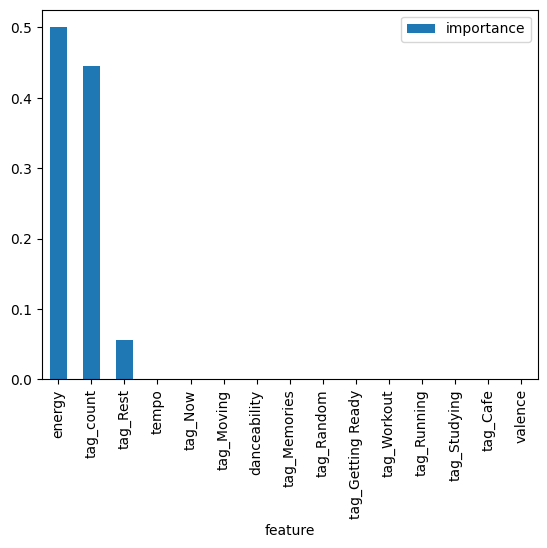

In [38]:
# 4. 중요 feature 상위 15개 시각화
importance_df.head(15).plot(
    x="feature",
    y="importance",
    kind="bar"
)

plt.xticks(rotation=90)
plt.show()

In [40]:
df.info()

#실제 뮤집 행동 데이터 구조 확인
#컬럼/타입 검증

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_id           5 non-null      int64  
 1   track_name         5 non-null      str    
 2   artist_name        5 non-null      str    
 3   danceability       5 non-null      float64
 4   energy             5 non-null      float64
 5   valence            5 non-null      float64
 6   tempo              5 non-null      int64  
 7   context_tags       5 non-null      str    
 8   liked              5 non-null      int64  
 9   tag_Now            5 non-null      int64  
 10  tag_count          5 non-null      int64  
 11  tag_Moving         5 non-null      int64  
 12  tag_Memories       5 non-null      int64  
 13  tag_Random         5 non-null      int64  
 14  tag_Rest           5 non-null      int64  
 15  tag_Getting Ready  5 non-null      int64  
 16  tag_Workout        5 non-null      int64 

In [43]:
df = pd.read_csv("../data/sample_music_context.csv")

df.columns

Index(['track_id', 'track_name', 'artist_name', 'danceability', 'energy',
       'valence', 'tempo', 'context_tags', 'liked', 'skipped', 'replayed'],
      dtype='str')

In [44]:
df["engagement_score"] = (
    df["liked"]*3 +
    df["replayed"]*2 -
    df["skipped"]*2
)

df[
[
"track_name",
"engagement_score"
]
]

,track_name,engagement_score
0,RUDE!,5
1,Graduation,5
2,Jasmine,-2
3,アイスコーヒー,-2


In [47]:
y = df["engagement_score"] > 1

# 좋아요 단일 예측 대신
# 실제 행동 기반 선호 예측

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 데이터 분리 및 학습 모델 로드
# 행동 점수 기반 추천 모델 재학습


In [50]:
X = df.drop(
    columns=[
        "track_id",
        "track_name",
        "artist_name",
        "context_tags",
        "engagement_score"
    ]
)

y = df["engagement_score"] > 1

In [51]:
print(X.columns)

Index(['danceability', 'energy', 'valence', 'tempo', 'liked', 'skipped',
       'replayed'],
      dtype='str')


In [52]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 학습/테스트 데이터 분리
# 미래 사용자 데이터 예측 상황 재현 

In [54]:
model=RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model.fit(X_train,y_train)

print(
    "Accuracy:",
    model.score(X_test,y_test)
)

# 행동 점수 기반 모델 학습
# 사용자 반응 예측 정확도 확인 

Accuracy: 0.0


In [56]:
importance_df=pd.DataFrame({
    "feature":X.columns,
    "importance":model.feature_importances_
})

importance_df=importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(10)

#어떤 태그와 음악 특성이
#실제 사용자 반응에 영향 주는지 분석

,feature,importance
1,energy,0.428571
0,danceability,0.142857
3,tempo,0.142857
6,replayed,0.142857
5,skipped,0.142857
2,valence,0.000000
4,liked,0.000000


In [64]:
X=df.drop(
columns=[
"track_id",
"track_name",
"artist_name",
"context_tags",
"engagement_score",
"liked",
"replayed",
"skipped"
]
)

#target 계산에 사용된 컬럼 제거
#데이터 누수(data leakage)방지

In [59]:
X.columns

Index(['danceability', 'energy', 'valence', 'tempo'], dtype='str')

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.0


In [62]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(10)

,feature,importance
1,energy,0.285714
2,valence,0.285714
3,tempo,0.285714
0,danceability,0.142857


In [66]:
print(df.columns)

Index(['track_id', 'track_name', 'artist_name', 'danceability', 'energy',
       'valence', 'tempo', 'context_tags', 'liked', 'skipped', 'replayed',
       'engagement_score'],
      dtype='str')


In [68]:
X = df.drop(
    columns=[
        "track_id",
        "track_name",
        "artist_name",
        "context_tags",
        "engagement_score",
        "liked",
        "replayed",
        "skipped"
    ]
)
# 학습에 필요 없는 메타 정보 제거
# target 계산에 사용한 컬럼 제거
# 데이터 누수(data leakage) 방지

In [69]:
print(X.columns)

Index(['danceability', 'energy', 'valence', 'tempo'], dtype='str')


In [70]:
for tag in MUGIP_TAGS:
    df[f"tag_{tag}"] = df["context_tags"].apply(
        lambda x: 1 if tag in str(x).split(",") else 0
    )

df["tag_count"] = df["context_tags"].apply(
    lambda x: len(str(x).split(","))
)

In [71]:
X = df.drop(
    columns=[
        "track_id",
        "track_name",
        "artist_name",
        "context_tags",
        "engagement_score",
        "liked",
        "replayed",
        "skipped"
    ]
)

print(X.columns)

Index(['danceability', 'energy', 'valence', 'tempo', 'tag_Now', 'tag_Moving',
       'tag_Memories', 'tag_Random', 'tag_Rest', 'tag_Getting Ready',
       'tag_Workout', 'tag_Running', 'tag_Studying', 'tag_Cafe', 'tag_Travel',
       'tag_School', 'tag_Reading', 'tag_Off Work', 'tag_Party', 'tag_Beach',
       'tag_Club', 'tag_Korea', 'tag_Tokyo', 'tag_U.S.A', 'tag_AirPods',
       'tag_Karaoke', 'tag_Band', 'tag_Mountain', 'tag_Driving',
       'tag_On the Road', 'tag_count'],
      dtype='str')


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.0


In [75]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

# 모델이 각 featrue (음악 특성/태그)를 얼마나 중요하게 사용했는지 저장
# feature_importances_ : RandomForest가 학습 후 계산한 중요도 점수

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)
# 상위 10개 중요 feature 출력
# MUGIP 추천에 실제 영향력이 높은 태그/오디오 특성 확인

importance_df.head(10)

,feature,importance
2,valence,0.285714
1,energy,0.142857
4,tag_Now,0.142857
6,tag_Memories,0.142857
5,tag_Moving,0.142857
8,tag_Rest,0.142857
0,danceability,0.000000
3,tempo,0.000000
7,tag_Random,0.000000
9,tag_Getting Ready,0.000000


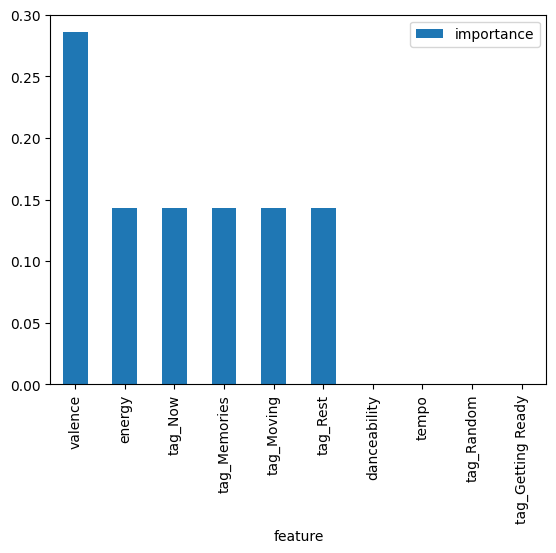

In [76]:
importance_df.head(10).plot(
    x="feature",
    y="importance",
    kind="bar"
)

# 중요 feature 상위 10개 시각화
# 사용자들의 행동(좋아요/재생/스킵)에 영향을 주는 요소 확인


plt.xticks(rotation=90)
#x축 태그 이름 회전 (겹침 방지)

plt.show()

# Feature Importance Analysis

## 목적
RandomForest 모델이 사용자의 행동(좋아요/재생/스킵)을 예측할 때  
어떤 음악 특성과 MUGIP 태그를 중요하게 사용하는지 분석하였다.

## 결과

상위 중요 feature:

1. valence
2. energy
3. tag_Now
4. tag_Memories
5. tag_Moving
6. tag_Rest

## 해석

이번 실험에서는 valence가 가장 높은 중요도를 보였다.

valence는 음악의 긍정적 감정 정도를 의미하며,
사용자의 반응(좋아요, 재생 등)에 가장 큰 영향을 준 것으로 나타났다.

또한 단순 오디오 특성뿐 아니라

- Now
- Memories
- Moving
- Rest

같은 MUGIP context tag도 높은 중요도를 보였다.

이는 사용자가 단순히 음악 자체만 반응하는 것이 아니라,
현재 상황(context)과 함께 음악을 소비한다는 가능성을 보여준다.

## MUGIP 관점 해석

기존 추천 시스템:

"어떤 음악을 좋아하는가"

MUGIP:

"언제, 어떤 상황에서 음악을 듣는가"

이번 실험은 context 기반 추천 구조가
사용자 행동 예측에 영향을 줄 수 있음을 확인하는 초기 결과이다.

## 한계

현재 데이터 수가 매우 적다.

샘플 수:
4개

따라서 feature importance는 참고 수준이며
실제 의미 있는 결과를 얻기 위해서는
100~1000개 이상의 로그 데이터가 필요하다.

## 다음 단계

- 실제 앱 로그 데이터 수집
- 태그 다양성 증가
- replay/skip 행동 추가
- GNN 기반 context recommendation 실험

그래프에 tag_Now가 올라온 건 꽤 MUGIP다운 결과, Spotify 스타일 오디오 특성만이 아니라 상황 태그 자체가 신호가 되기 시작한 것이라 방향은 OK